# LAB_5


     TESTIRANJE SIMULATED ANNEALING ALGORITMA

Parametri:
  Početna temperatura T0 = 200.0
  Faktor hlađenja α = 0.99
  Broj iteracija po T: K = 100
  Maksimalan broj iteracija: N = 1000
  Korak delta_x = 0.1
  Epsilon = 0

FUNKCIJA: Paraboloid: $f(x_1,x_2) = x_1^2 + x_2^2$
Početna tačka: x0 = [4, 4]

SA rezultat:
  x = [-0.000000, 0.000000]
  f(x) = 0.0000000000

Globalni minimum:
  x = [0, 0]
  f(x) = 0.0000000000

Apsolutna greška: 0.0000000000
✅ ODLIČNO - Pronađen veoma tačan minimum!


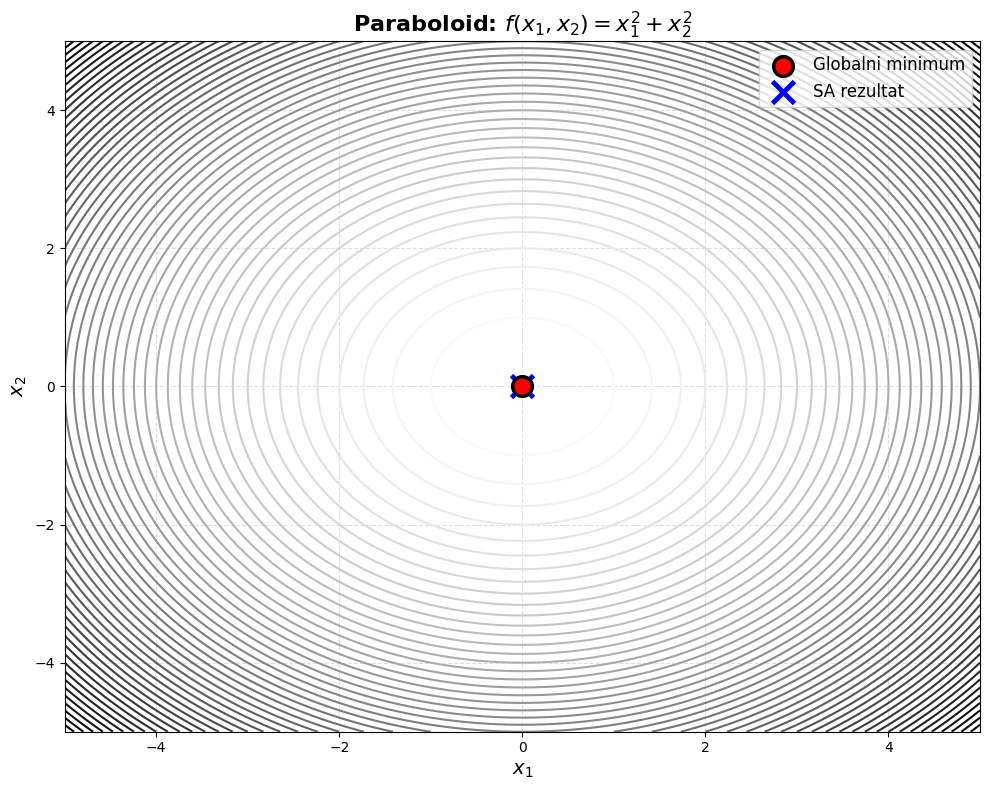


FUNKCIJA: Rastrigin
Početna tačka: x0 = [4, 4]

SA rezultat:
  x = [0.020000, -0.020000]
  f(x) = 0.1585059737

Globalni minimum:
  x = [0, 0]
  f(x) = 0.0000000000

Apsolutna greška: 0.1585059737
⚠️ UPOZORENJE - Odstupanje od globalnog minimuma


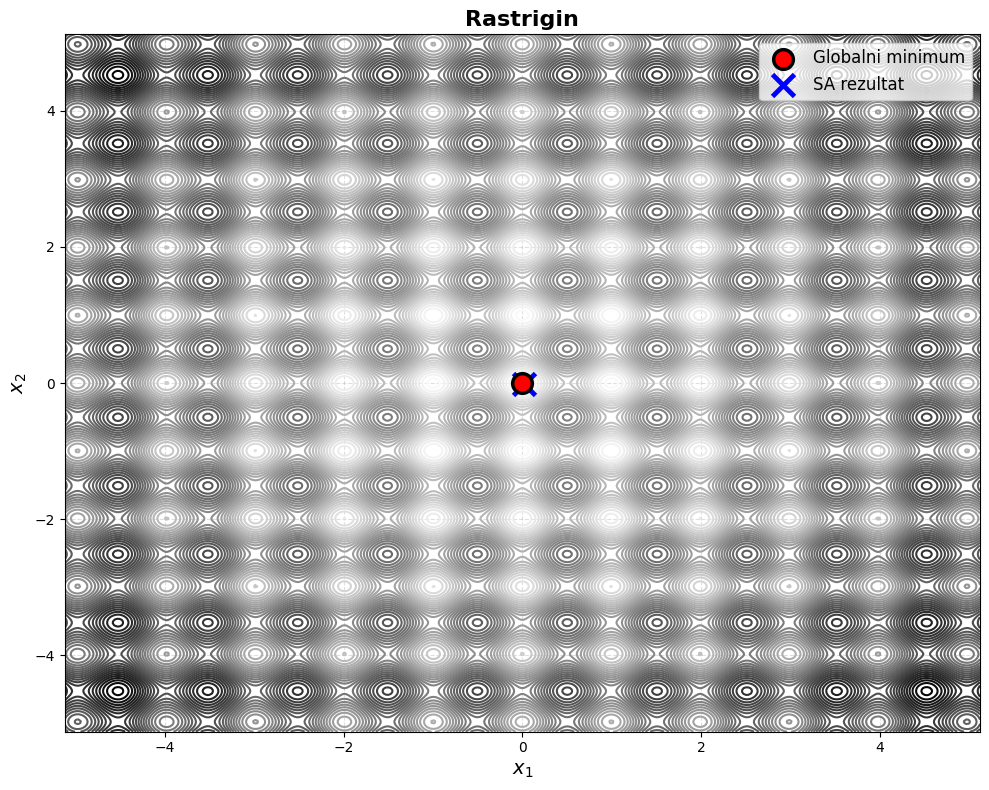


FUNKCIJA: Drop-Wave
Početna tačka: x0 = [3, 3]

SA rezultat:
  x = [0.020000, 0.020000]
  f(x) = -0.9712811643

Globalni minimum:
  x = [0, 0]
  f(x) = -1.0000000000

Apsolutna greška: 0.0287188357
Relativna greška: 2.871884%
✓ DOBRO - Pronađen zadovoljavajući minimum


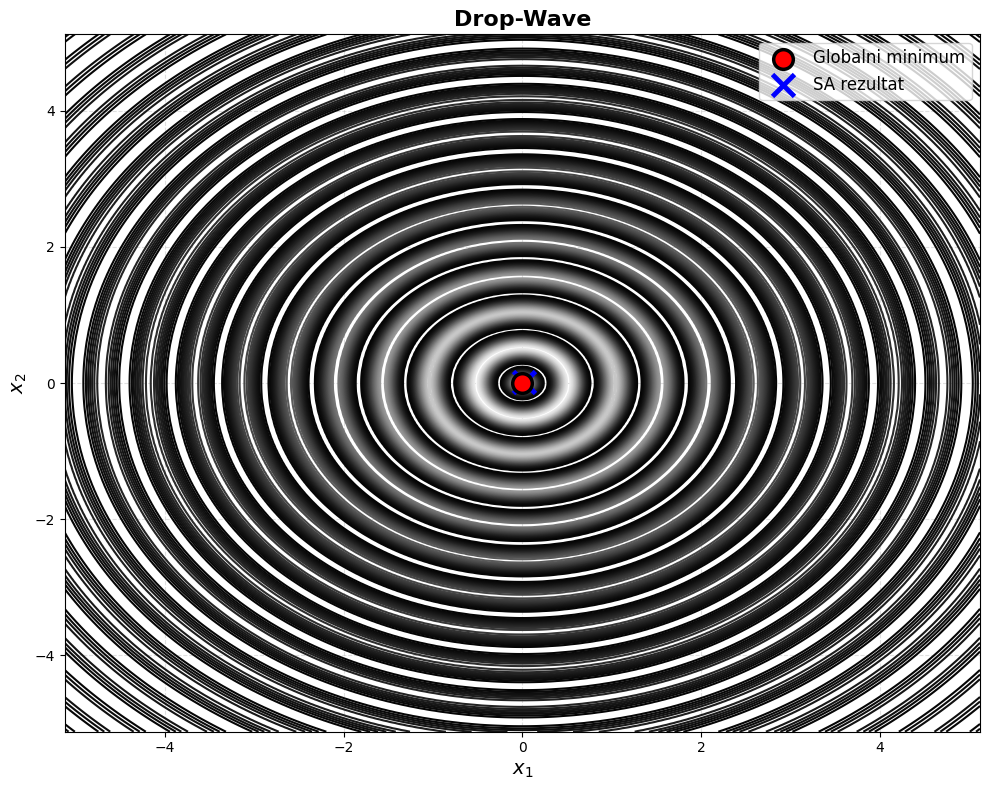


FUNKCIJA: Holder Table
Početna tačka: x0 = [5, 5]

SA rezultat:
  x = [-8.100000, 9.700000]
  f(x) = -19.1753593598

Globalni minimum:
  Broj globalnih minimuma: 4
  Primjer: x = [8.05502, 9.66459]
  f(x) = -19.2085025678

Apsolutna greška: 0.0331432080
Relativna greška: 0.172544%
✓ DOBRO - Pronađen zadovoljavajući minimum


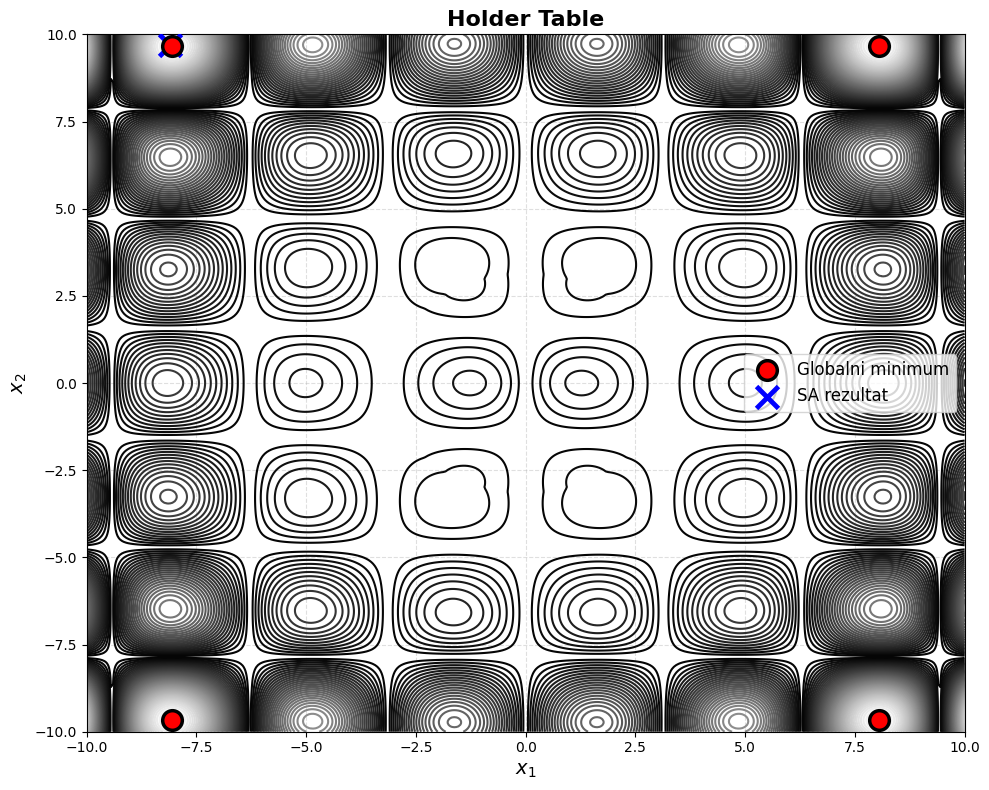

In [ ]:
# ============================================================================
# LABORATORIJSKA VJEŽBA 5: Simulirano hlađenje (Simulated Annealing)
# Predmet: Optimizacija resursa
# Univerzitet u Sarajevu - Elektrotehnički fakultet
# ============================================================================

"""
# 📚 Uvod

Ova laboratorijska vježba demonstrira implementaciju i primjenu
**algoritma simuliranog hlađenja (Simulated Annealing)** za traženje
globalnih minimuma funkcija.

## Teorijska osnova

Simulirano hlađenje imitira proces hlađenja metala:
- Na **visokim temperaturama**: Prihvata i lošija rješenja (eksploracija)
- Na **niskim temperaturama**: Prihvata samo bolja rješenja (eksploatacija)

### Vjerovatnoća prihvatanja lošijeg rješenja:
$$p = e^{-\\frac{|v - v'|}{T}}$$

gdje je T temperatura koja se postepeno smanjuje.
"""

# ============================================================================
# IMPORTOVANJE BIBLIOTEKA
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import itertools

# ============================================================================
# ZADATAK 1: IMPLEMENTACIJA SIMULATED ANNEALING ALGORITMA
# ============================================================================

"""
# 🔧 Zadatak 1: Implementacija Simulated Annealing algoritma

Funkcija SA prima:
- `f`: kriterijalna funkcija
- `opseg`: opseg pretraživanja
- `x0`: početna tačka
- `delta_x`: korak diskretizacije
- `N`: maksimalan broj iteracija
- `eps`: minimalna promjena funkcije
- `T0`: početna temperatura
"""

def SA(f, opseg, x0, delta_x, N, eps, T0, alpha=0.95, K=100):
    """
    Simulated Annealing algoritam za traženje globalnog minimuma.

    Parametri:
    ----------
    f : function
        Kriterijalna funkcija za minimizaciju
    opseg : list of tuples
        Opseg pretraživanja [(x1_min, x1_max), (x2_min, x2_max), ...]
    x0 : list
        Početna tačka pretraživanja
    delta_x : float
        Veličina koraka diskretizacije
    N : int
        Maksimalan broj spoljašnjih iteracija (broj smanjenja temperature)
    eps : float
        Minimalna promjena vrijednosti funkcije
    T0 : float
        Početna temperatura
    alpha : float, optional
        Faktor hlađenja (default: 0.95)
    K : int, optional
        Broj unutrašnjih iteracija po temperaturi (default: 100)

    Vraća:
    -------
    x_best : np.array
        Najbolja pronađena tačka
    v_best : float
        Vrijednost funkcije u najboljoj tačci
    """

    # INICIJALIZACIJA (linija 1 pseudokoda)
    x = np.array(x0, dtype=float)      # Trenutna tačka
    x_best = x.copy()                  # Najbolja tačka dosad
    v_best = f(*x_best)                # Najbolja vrijednost dosad

    T = T0  # Trenutna temperatura

    n_dim = len(opseg)  # Broj dimenzija

    v_prethodno = v_best  # Za praćenje promjene

    # GLAVNA PETLJA (linija 2-16)
    for iter_spoljasnja in range(N):

        # UNUTRAŠNJA PETLJA - K iteracija na fiksnoj temperaturi (linija 3-14)
        for iter_unutrasnja in range(K):

            # Trenutna vrijednost funkcije (linija 4)
            v = f(*x)

            # Generiši RANDOM susjeda iz okoline N(x) (linija 5)
            x_novi = x.copy()

            # Random pomjeranje u svakoj dimenziji: -1, 0, ili +1
            for dim in range(n_dim):
                pomjeranje = np.random.choice([-1, 0, 1])
                x_novi[dim] += pomjeranje * delta_x

                # Provjeri granice - ako je van, vrati unutra
                if x_novi[dim] < opseg[dim][0]:
                    x_novi[dim] = opseg[dim][0]
                elif x_novi[dim] > opseg[dim][1]:
                    x_novi[dim] = opseg[dim][1]

            # Izračunaj vrijednost u novoj tački (linija 6)
            v_novi = f(*x_novi)

            # ODLUKA O PRIHVATANJU (linija 7-12)
            if v_novi < v:  # Ako je bolje, UVIJEK prihvati
                x = x_novi
                v = v_novi
            else:  # Ako je lošije, prihvati sa vjerovatnoćom p
                # Metropolis kriterijum
                delta_v = abs(v - v_novi)
                p = np.exp(-delta_v / T)  # Vjerovatnoća prihvatanja

                if np.random.rand() < p:  # Prihvati sa vjerovatnoćom p
                    x = x_novi
                    v = v_novi

            # AŽURIRAJ GLOBALNO NAJBOLJE RJEŠENJE (linija 13)
            if v < v_best:
                x_best = x.copy()
                v_best = v

        # AŽURIRAJ TEMPERATURU - geometrijsko hlađenje (linija 15)
        T = alpha * T

        # USLOV ZAUSTAVLJANJA (linija 16)
        if abs(v_best - v_prethodno) < eps and T < 0.01:
            print(f"  ✓ Konvergencija nakon {iter_spoljasnja + 1} iteracija")
            break

        v_prethodno = v_best

    return x_best, v_best


# ============================================================================
# TESTNE FUNKCIJE
# ============================================================================

"""
# 📊 Test funkcije

Definirat ćemo sve test funkcije:
1. Paraboloid
2. Rastrigin
3. Drop-Wave
4. Holder Table
"""

def paraboloid(x1, x2):
    """Paraboloid: f(x1,x2) = x1^2 + x2^2
    Globalni minimum: (0, 0), f = 0
    """
    return x1**2 + x2**2


def rastrigin(x1, x2):
    """Rastrigin funkcija - visoko multimodalna
    Globalni minimum: (0, 0), f = 0
    """
    A = 10
    return A*2 + (x1**2 - A*np.cos(2*np.pi*x1)) + (x2**2 - A*np.cos(2*np.pi*x2))


def drop_wave(x1, x2):
    """Drop-Wave funkcija
    Globalni minimum: (0, 0), f ≈ -1
    """
    num = 1 + np.cos(12*np.sqrt(x1**2 + x2**2))
    den = 0.5*(x1**2 + x2**2) + 2
    return -num/den


def holder_table(x1, x2):
    """Holder Table funkcija
    Globalni minimumi: (±8.05502, ±9.66459), f ≈ -19.2085
    """
    return -np.abs(np.sin(x1)*np.cos(x2)*np.exp(np.abs(1 - np.sqrt(x1**2 + x2**2)/np.pi)))



# ============================================================================
# FUNKCIJA ZA VIZUALIZACIJU
# ============================================================================

"""
# 📈 Funkcija za vizualizaciju rezultata

Crta crno-bijeli contour plot sa:
- Globalnim minimumom (crveni kružić ◦)
- SA rezultatom (plavi križić ×)
"""

def plot_rezultati_sa(f, opseg, naziv, globalni_min, x_sa):
    """
    Crta contour plot sa rezultatima Simulated Annealing algoritma.

    Parametri:
    ----------
    f : function
        Funkcija za crtanje
    opseg : list
        [(x1_min, x1_max), (x2_min, x2_max)]
    naziv : str
        Naziv funkcije
    globalni_min : list
        Lista globalnih minimuma [[x1, x2], ...]
    x_sa : np.array
        Rezultat SA algoritma
    """
    x1 = np.linspace(opseg[0][0], opseg[0][1], 400)
    x2 = np.linspace(opseg[1][0], opseg[1][1], 400)
    X1, X2 = np.meshgrid(x1, x2)
    Y = f(X1, X2)

    plt.figure(figsize=(10, 8))

    # Crno-bijeli contour plot
    plt.contour(X1, X2, Y, 50, cmap='binary')

    # Globalni minimum(i) - crveni kružić
    for idx, gm in enumerate(globalni_min):
        plt.scatter(gm[0], gm[1], color='red', marker='o',
                    s=200, label='Globalni minimum' if idx == 0 else '',
                    zorder=5, edgecolors='black', linewidths=2.5)

    # SA rezultat - plavi križić
    plt.scatter(x_sa[0], x_sa[1], color='blue', marker='x',
                s=250, label='SA rezultat', linewidths=3.5, zorder=4)

    # Postavljanje labela i mreže
    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$x_2$', fontsize=14)
    plt.title(naziv, fontsize=16, fontweight='bold')
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()


# ============================================================================
# ZADATAK 2: TESTIRANJE NA FUNKCIJAMA
# ============================================================================

"""
# 🧪 Zadatak 2: Testiranje Simulated Annealing algoritma

Testiramo SA na 4 funkcije:
1. Paraboloid
2. Rastrigin
3. Drop-Wave
4. Holder Table
"""

# Postavke algoritma
delta_x = 0.1
N = 1000       # Broj spoljašnjih iteracija
eps = 0
T0 = 200.0     # Početna temperatura
alpha = 0.99   # Faktor hlađenja
K = 100        # Broj iteracija po temperaturi

# Lista funkcija za testiranje
testovi = [
    {
        'f': paraboloid,
        'opseg': [[-5, 5], [-5, 5]],
        'x0': [4, 4],
        'globalni_min': [[0, 0]],
        'naziv': 'Paraboloid: $f(x_1,x_2) = x_1^2 + x_2^2$'
    },
    {
        'f': rastrigin,
        'opseg': [[-5.12, 5.12], [-5.12, 5.12]],
        'x0': [4, 4],
        'globalni_min': [[0, 0]],
        'naziv': 'Rastrigin'
    },
    {
        'f': drop_wave,
        'opseg': [[-5.12, 5.12], [-5.12, 5.12]],
        'x0': [3, 3],
        'globalni_min': [[0, 0]],
        'naziv': 'Drop-Wave'
    },
    {
        'f': holder_table,
        'opseg': [[-10, 10], [-10, 10]],
        'x0': [5, 5],
        'globalni_min': [
            [8.05502, 9.66459],
            [8.05502, -9.66459],
            [-8.05502, 9.66459],
            [-8.05502, -9.66459]
        ],
        'naziv': 'Holder Table'
    }
]

# Pokreni testove
print("\n" + "="*70)
print("     TESTIRANJE SIMULATED ANNEALING ALGORITMA")
print("="*70)
print(f"\nParametri:")
print(f"  Početna temperatura T0 = {T0}")
print(f"  Faktor hlađenja α = {alpha}")
print(f"  Broj iteracija po T: K = {K}")
print(f"  Maksimalan broj iteracija: N = {N}")
print(f"  Korak delta_x = {delta_x}")
print(f"  Epsilon = {eps}")

for test in testovi:
    print(f"\n{'='*70}")
    print(f"FUNKCIJA: {test['naziv']}")
    print(f"{'='*70}")
    print(f"Početna tačka: x0 = {test['x0']}")

    # SIMULATED ANNEALING
    x_sa, v_sa = SA(test['f'], test['opseg'], test['x0'],
                    delta_x, N, eps, T0, alpha, K)

    print(f"\nSA rezultat:")
    print(f"  x = [{x_sa[0]:.6f}, {x_sa[1]:.6f}]")
    print(f"  f(x) = {v_sa:.10f}")

    # Globalni minimum
    v_global = test['f'](*test['globalni_min'][0])
    print(f"\nGlobalni minimum:")
    if len(test['globalni_min']) == 1:
        print(f"  x = {test['globalni_min'][0]}")
    else:
        print(f"  Broj globalnih minimuma: {len(test['globalni_min'])}")
        print(f"  Primjer: x = {test['globalni_min'][0]}")
    print(f"  f(x) = {v_global:.10f}")

    # Greška
    greska_sa = abs(v_sa - v_global)
    print(f"\nApsolutna greška: {greska_sa:.10f}")

    if v_global != 0:
        relativna_greska = (greska_sa / abs(v_global)) * 100
        print(f"Relativna greška: {relativna_greska:.6f}%")

    # Ocjena tačnosti
    if greska_sa < 1e-3:
        print("✅ ODLIČNO - Pronađen veoma tačan minimum!")
    elif greska_sa < 1e-1:
        print("✓ DOBRO - Pronađen zadovoljavajući minimum")
    else:
        print("⚠️ UPOZORENJE - Odstupanje od globalnog minimuma")

    # Crtaj grafik
    plot_rezultati_sa(test['f'], test['opseg'], test['naziv'],
                      test['globalni_min'], x_sa)